PANDAS

In [29]:
import pandas as pd

data = {
    'Product': ['Laptop', 'Mouse', 'Monitor', 'Keyboard', 'Mouse', 'Monitor'],
    'Price': [1200, 25, None, 75, 25, 150],
    'Stock': [5, 50, 10, None, 50, 8],
    'Category': ['Electronics', 'Accessories', 'Electronics', 'Accessories', 'Accessories', 'Electronics']
}

banana = pd.DataFrame(data)
# banana=pd.read_csv("C:\\Users\\HP\\Downloads\\global_natural_disasters_2000_2025.csv")
print(banana.head())
print("--------------------------------------------------------------")
print(banana.tail())
print("--------------------------------------------------------------")
print(banana.info())
print("--------------------------------------------------------------")
print(banana.describe())
print("--------------------------------------------------------------")
print(banana.columns)
print("--------------------------------------------------------------")
print(banana.shape)
print("--------------------------------------------------------------")
print(banana.isnull().sum())
print("--------------------------------------------------------------")
print(banana.dropna(inplace=True))
print("--------------------------------------------------------------")
banana['Price'] = banana['Price'].fillna(banana['Price'].mean())
print(banana)
print("--------------------------------------------------------------")
high_price = banana[banana['Price'] > 100] 
print(high_price)

    Product   Price  Stock     Category
0    Laptop  1200.0    5.0  Electronics
1     Mouse    25.0   50.0  Accessories
2   Monitor     NaN   10.0  Electronics
3  Keyboard    75.0    NaN  Accessories
4     Mouse    25.0   50.0  Accessories
--------------------------------------------------------------
    Product  Price  Stock     Category
1     Mouse   25.0   50.0  Accessories
2   Monitor    NaN   10.0  Electronics
3  Keyboard   75.0    NaN  Accessories
4     Mouse   25.0   50.0  Accessories
5   Monitor  150.0    8.0  Electronics
--------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Product   6 non-null      str    
 1   Price     5 non-null      float64
 2   Stock     5 non-null      float64
 3   Category  6 non-null      str    
dtypes: float64(2), str(2)
memory usage: 324.0 bytes
None
-------------------

NUMPY

In [ ]:
import numpy as np

arr1d = np.array([1, 2, 3, 4, 5, 6])

arr2d = np.array([[1, 2, 3], [4, 5, 6]])

print(f"Shape: {arr2d.shape}")   
print(f"Dims:  {arr2d.ndim}")    
print(f"Type:  {arr2d.dtype}")   
print(f"Size:  {arr2d.size}")   


# Math operations
print(arr1d + 10)  
print(arr1d * 2)   

# Statistics
print(np.mean(arr1d))  
print(np.median(arr1d)) 
print(np.std(arr1d))    
print(np.sum(arr2d, axis=0))  



print(arr2d[0, 1:3])

# Turn our 6-element 1D array into a 3x2 2D array
reshaped = arr1d.reshape(3, 2)
print(reshaped)

row_adder = np.array([10, 20, 30])
result = arr2d + row_adder
print(result)

Shape: (2, 3)
Dims:  2
Type:  int64
Size:  6
[11 12 13 14 15 16]
[ 2  4  6  8 10 12]
3.5
3.5
1.707825127659933
[5 7 9]
[2 3]
[[1 2]
 [3 4]
 [5 6]]
[[11 22 33]
 [14 25 36]]


PYSPARK

In [ ]:
import pandas as pd
import os
os.environ["JAVA_HOME"]   = r"C:\Program Files\Java\jdk-17"
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] = r"C:\Program Files\Java\jdk-17\bin;" + os.environ["PATH"]
os.environ["PYSPARK_PYTHON"] = r"c:\Git\.venv\Scripts\python.exe"

# Remove SPARK_HOME completely
if "SPARK_HOME" in os.environ:
    del os.environ["SPARK_HOME"]

from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

spark = SparkSession.builder \
    .master("local[2]") \
    .appName("bigdata") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

print("Ready:", spark.version)

data = {
    'Product': ['Laptop', 'Mouse', 'Monitor', 'Keyboard', 'Mouse', 'Monitor'],
    'Price': [1200, 25, None, 75, 25, 150],
    'Stock': [5, 50, 10, None, 50, 8],
    'Category': ['Electronics', 'Accessories', 'Electronics', 'Accessories', 'Accessories', 'Electronics']
}

df = pd.DataFrame(data)
spark_df = spark.createDataFrame(df)
spark_df.show()
spark_df.select("Product", "Price").show()
spark_df.filter(spark_df.Price > 100).show()
spark_df.groupBy("Category").count().show()

print("---------------------------------------------------------------")
spark_df.printSchema()


print("---------------------------------------------------------------")
# 4. Register as a SQL Temporary View
spark_df.createOrReplaceTempView("store")

# 5. Execute SQL Queries
print("--- Full Dataset ---")
spark.sql("SELECT * FROM store").show()

print("--- Total Inventory Value per Category ---")
spark.sql("""
    SELECT Category, SUM(Price * Stock) as Total_Value 
    FROM store 
    WHERE Price IS NOT NULL AND Stock IS NOT NULL 
    GROUP BY Category
""").show()

print("--- Products with Stock < 10 ---")
spark.sql("SELECT Product, Stock FROM store WHERE Stock < 10").show()

print("--- Average Price of Unique Products ---")
spark.sql("SELECT AVG(DISTINCT Price) as Avg_Unique_Price FROM store").show()




# PySpark is essential for big data because it processes massive datasets in parallel across a cluster of computers using In-Memory computing, making it significantly faster than traditional disk-based systems. It allows developers to use Python's simple syntax to scale data processing from a single laptop to petabytes of data seamlessly.

Ready: 4.1.1
+--------+------+-----+-----------+
| Product| Price|Stock|   Category|
+--------+------+-----+-----------+
|  Laptop|1200.0|  5.0|Electronics|
|   Mouse|  25.0| 50.0|Accessories|
| Monitor|   NaN| 10.0|Electronics|
|Keyboard|  75.0|  NaN|Accessories|
|   Mouse|  25.0| 50.0|Accessories|
| Monitor| 150.0|  8.0|Electronics|
+--------+------+-----+-----------+

+--------+------+
| Product| Price|
+--------+------+
|  Laptop|1200.0|
|   Mouse|  25.0|
| Monitor|   NaN|
|Keyboard|  75.0|
|   Mouse|  25.0|
| Monitor| 150.0|
+--------+------+

+-------+------+-----+-----------+
|Product| Price|Stock|   Category|
+-------+------+-----+-----------+
| Laptop|1200.0|  5.0|Electronics|
|Monitor|   NaN| 10.0|Electronics|
|Monitor| 150.0|  8.0|Electronics|
+-------+------+-----+-----------+

+-----------+-----+
|   Category|count|
+-----------+-----+
|Electronics|    3|
|Accessories|    3|
+-----------+-----+

---------------------------------------------------------------
root
 |-- Prod

MATPLOTLIB

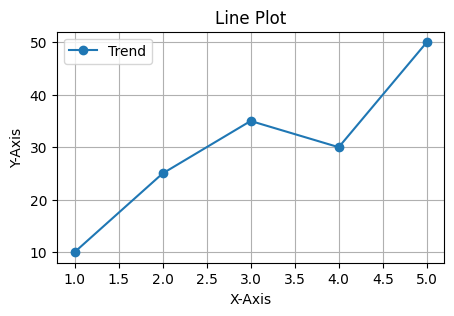

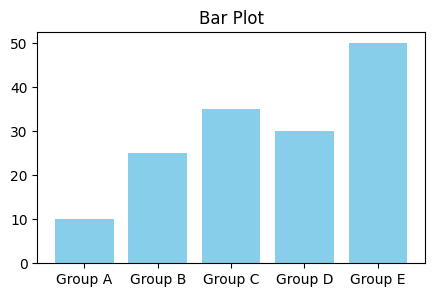

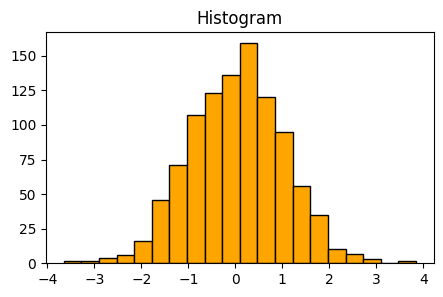

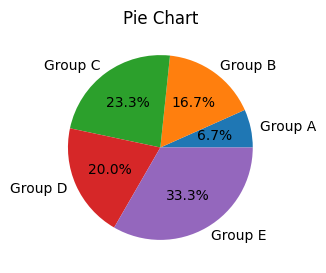

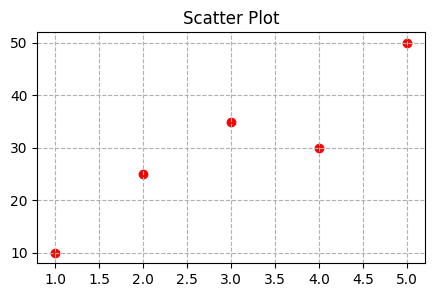

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 25, 35, 30, 50])
labels = ['Group A', 'Group B', 'Group C', 'Group D', 'Group E']
dist_data = np.random.randn(1000)

# --- LINE PLOT ---
plt.figure(figsize=(5, 3))
plt.plot(x, y, marker='o', label='Trend')
plt.title("Line Plot")
plt.xlabel("X-Axis")
plt.ylabel("Y-Axis")
plt.legend()
plt.grid(True)
plt.savefig('line.png')
plt.show()

# --- BAR PLOT ---
plt.figure(figsize=(5, 3))
plt.bar(labels, y, color='skyblue')
plt.title("Bar Plot")
plt.savefig('bar.png')
plt.show()

# --- HISTOGRAM ---
plt.figure(figsize=(5, 3))
# Note: 'edgecolor' has NO hyphen
plt.hist(dist_data, bins=20, color='orange', edgecolor='black') 
plt.title("Histogram")
plt.savefig('hist.png')
plt.show()

# --- PIE CHART ---
plt.figure(figsize=(5, 3))
plt.pie(y, labels=labels, autopct='%1.1f%%')
plt.title("Pie Chart")
plt.savefig('pie.png')
plt.show()

# --- SCATTER PLOT ---
plt.figure(figsize=(5, 3))
plt.scatter(x, y, color='red')
plt.title("Scatter Plot")
plt.grid(linestyle='--')
plt.savefig('scatter.png')
plt.show()

SEABORN

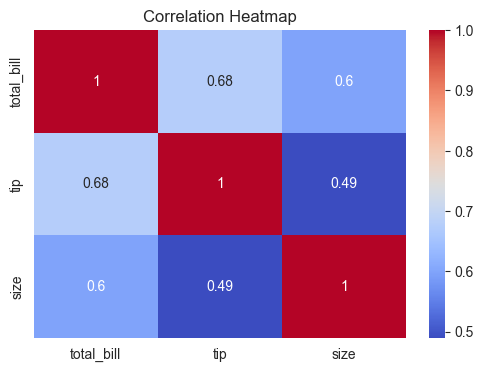

C:\Users\HP\AppData\Local\Temp\ipykernel_36416\4233028322.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='total_bill', data=tips, palette='Set2')


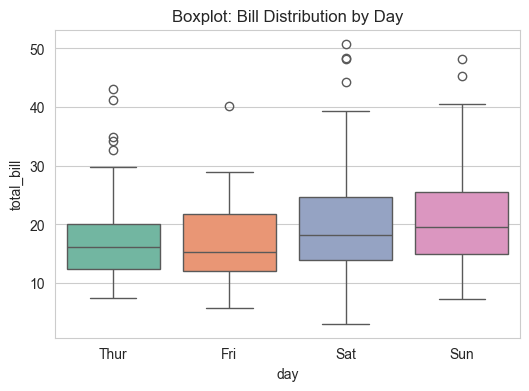

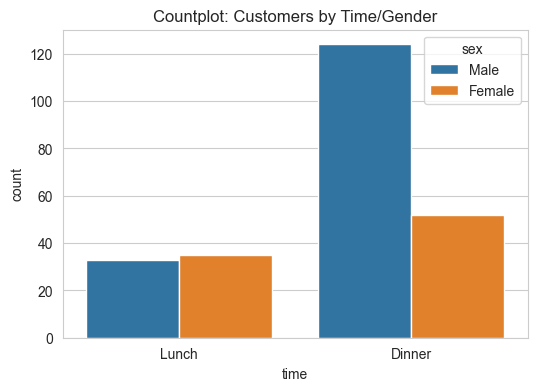

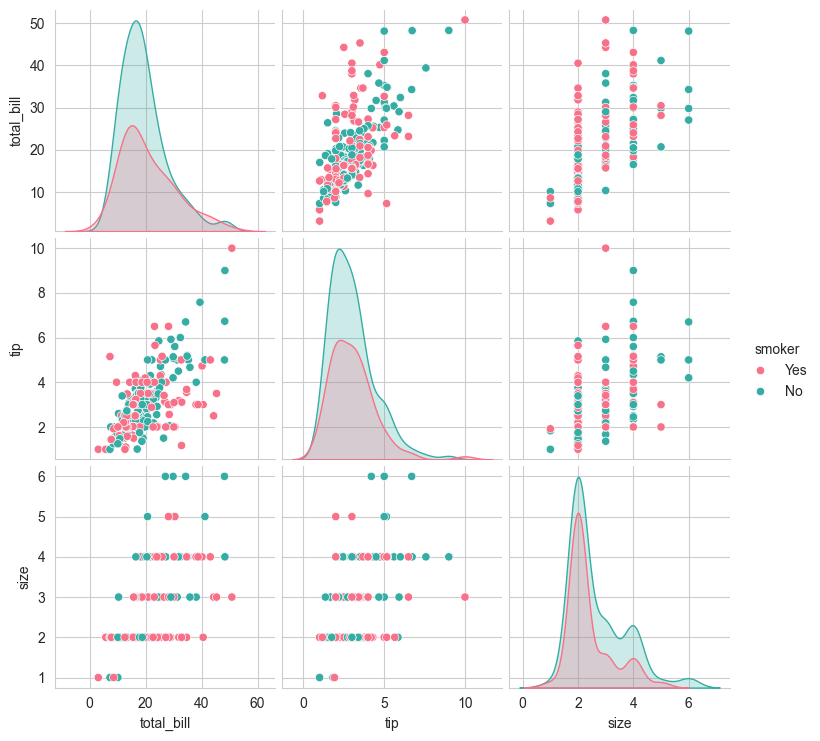

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Load built-in dataset
tips = sns.load_dataset("tips")

# --- 2. Heatmap ---
plt.figure(figsize=(6, 4))
corr = tips.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# --- 3. Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='day', y='total_bill', data=tips, palette='Set2')
plt.title("Boxplot: Bill Distribution by Day")
plt.show()

# --- 4. Countplot ---
plt.figure(figsize=(6, 4))
sns.countplot(x='time', data=tips, hue='sex')
plt.title("Countplot: Customers by Time/Gender")
plt.show()

# --- 5. Pairplot 
sns.pairplot(tips, hue='smoker', palette='husl')
plt.show()





SCIPY


In [54]:
from scipy import stats
import seaborn as sns

# Load data
tips = sns.load_dataset("tips")
smokers = tips[tips['smoker'] == 'Yes']['tip']
non_smokers = tips[tips['smoker'] == 'No']['tip']

# Perform Independent T-test
t_stat, p_value = stats.ttest_ind(smokers, non_smokers)
print("\n--- T-Test Example ---")

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# Logic: If p_value < 0.05, the difference is significant
if p_value < 0.05:
    print("Result: Significant difference in tipping habits.")
else:
    print("Result: No significant difference found.")
    
    
# --------------------------OPTIMIZATION-----------------------------
print("\n--- Optimization Example ---")
from scipy.optimize import minimize

# Define a simple quadratic function: f(x) = x^2 + x + 2
def objective_function(x):
    return x**2 + x + 2

# Find the 'x' value that results in the lowest 'y'
result = minimize(objective_function, x0=0) # x0 is the starting guess

print(f"Minimum value found at x = {result.x[0]:.4f}")

print("\n--- Integration Example ---")

from scipy.integrate import quad

# Define a function: f(x) = x^2
def function_to_integrate(x):
    return x**2

# Integrate x^2 from 0 to 1
area, error = quad(function_to_integrate, 0, 1)

print(f"The area under the curve (Integral) is: {area:.4f}")


--- T-Test Example ---
T-Statistic: 0.0922
P-Value: 0.9266
Result: No significant difference found.

--- Optimization Example ---
Minimum value found at x = -0.5000

--- Integration Example ---
The area under the curve (Integral) is: 0.3333


SK LEARN

In [55]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

# --- 1. Load and Preprocess ---
df = sns.load_dataset('iris')
# Convert species to numbers for the models
df['species_cat'] = df['species'].astype('category').cat.codes

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_cat'] # Classification target
y_reg = df['petal_width'] # Regression target (predicting a continuous number)

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Crucial for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Implement Models ---

# A. Linear Regression (Predicting a number, e.g., Petal Width)
# We split separately for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X[['sepal_length']], y_reg, test_size=0.2)
lin_reg = LinearRegression().fit(X_train_r, y_train_r)
print(f"Linear Regression MSE: {mean_squared_error(y_test_r, lin_reg.predict(X_test_r)):.4f}")

# B. Logistic Regression (Classification)
log_reg = LogisticRegression().fit(X_train_scaled, y_train)

# C. Decision Tree
dtree = DecisionTreeClassifier().fit(X_train, y_train)

# D. KNN (K-Nearest Neighbors)
knn = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)

# --- 3. Evaluate ---
models = {"Logistic Regression": log_reg, "Decision Tree": dtree, "KNN": knn}

for name, model in models.items():
    # Use scaled data for LogReg and KNN, raw for Tree
    data = X_test_scaled if name != "Decision Tree" else X_test
    preds = model.predict(data)
    
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

Linear Regression MSE: 0.2253

--- Logistic Regression ---
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- Decision Tree ---
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- KNN ---
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
